In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

In [17]:
class StaticNdLinear(nn.Module):
    def __init__(self, in_dims, out_dims, num_classes=2):
        super().__init__()
        D1, D2 = in_dims
        H1, H2 = out_dims
        self.H1, self.H2 = H1, H2

        self.lin1 = nn.Linear(D1, H1)
        self.lin2 = nn.Linear(D2, H2)
        self.classifier = nn.Linear(H1 * H2, num_classes)

    def forward(self, x):
        B, D1, D2 = x.shape
        y = x.permute(0, 2, 1).reshape(B * D2, D1)
        y = self.lin1(y).view(B, D2, self.H1).permute(0, 2, 1)
        y = y.reshape(B * self.H1, D2)
        y = self.lin2(y).view(B, -1)
        return self.classifier(y)

In [18]:
def prepare_imdb_data(seq_len=200, vocab_size=10000):
    dataset = load_dataset('imdb')
    tokenizer = lambda text: text.lower().split()
    counter = Counter()
    for example in dataset['train']:
        counter.update(tokenizer(example['text']))
    most_common = counter.most_common(vocab_size - 2)
    vocab = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
    vocab['<unk>'] = 0
    vocab['<pad>'] = 1

    def encode(text):
        tokens = tokenizer(text)
        ids = [vocab.get(token, 0) for token in tokens]
        return ids[:seq_len] + [1] * max(0, seq_len - len(ids))

    X_train = torch.tensor([encode(ex['text']) for ex in dataset['train']])
    y_train = torch.tensor([ex['label'] for ex in dataset['train']])
    X_test = torch.tensor([encode(ex['text']) for ex in dataset['test']])
    y_test = torch.tensor([ex['label'] for ex in dataset['test']])

    return X_train, y_train, X_test, y_test, vocab

In [19]:
def train(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        optimizer.step()
        preds = out.argmax(1)
        total_loss += loss.item() * xb.size(0)
        total_correct += (preds == yb).sum().item()
        total_samples += xb.size(0)
    return total_loss / total_samples, total_correct / total_samples

In [20]:
def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds = out.argmax(1)
            all_preds.append(preds.cpu())
            all_labels.append(yb.cpu())

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [21]:
def plot_metrics(losses, accs):
    epochs = range(1, len(losses) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, losses, marker='o')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accs, marker='o', color='green')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid()

    plt.tight_layout()
    plt.show()

Epoch  1 — Loss: 0.6771, Acc: 0.5607
Epoch  2 — Loss: 0.5227, Acc: 0.7395
Epoch  3 — Loss: 0.4013, Acc: 0.8206
Epoch  4 — Loss: 0.3237, Acc: 0.8619
Epoch  5 — Loss: 0.2661, Acc: 0.8904
Epoch  6 — Loss: 0.2247, Acc: 0.9099
Epoch  7 — Loss: 0.1808, Acc: 0.9306
Epoch  8 — Loss: 0.1444, Acc: 0.9463
Epoch  9 — Loss: 0.1082, Acc: 0.9628
Epoch 10 — Loss: 0.0794, Acc: 0.9750


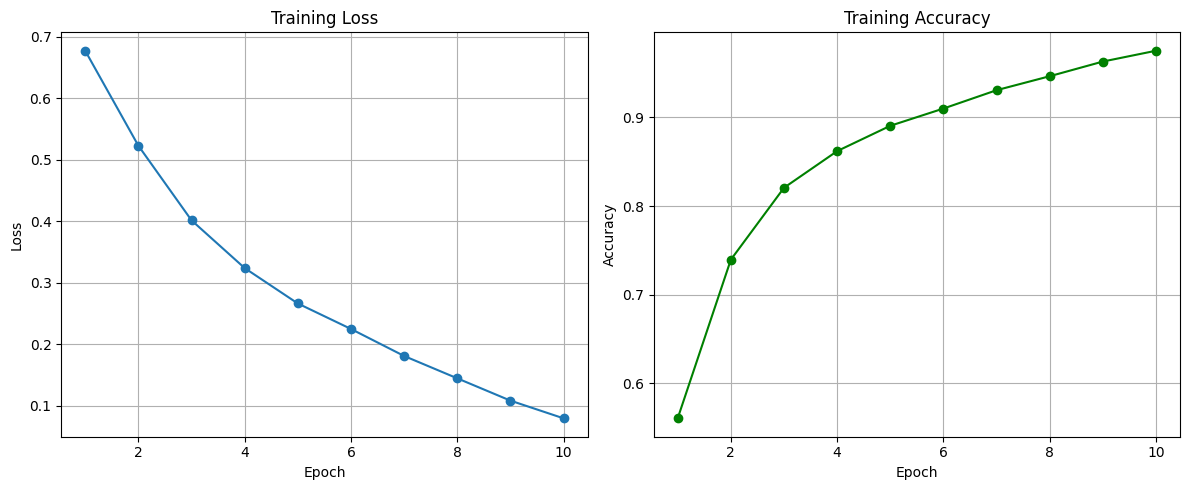


Classification Report:
              precision    recall  f1-score   support

           0     0.8268    0.7736    0.7993     12500
           1     0.7873    0.8380    0.8119     12500

    accuracy                         0.8058     25000
   macro avg     0.8071    0.8058    0.8056     25000
weighted avg     0.8071    0.8058    0.8056     25000



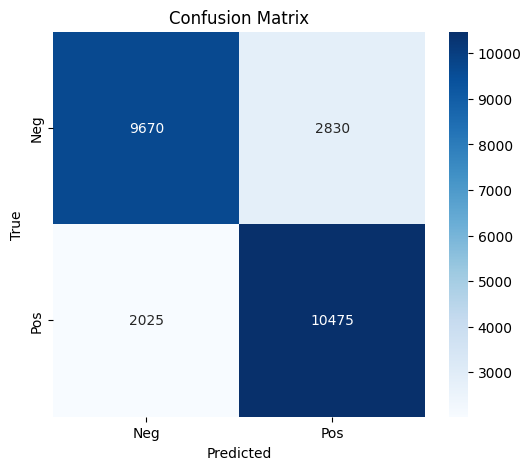

In [22]:
def run_static_ndlinear_imdb():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_train, y_train, X_test, y_test, vocab = prepare_imdb_data()
    train_ds = TensorDataset(X_train, y_train)
    test_ds = TensorDataset(X_test, y_test)
    train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
    test_dl = DataLoader(test_ds, batch_size=128)

    embed_dim = 64
    embedding = nn.Embedding(10000, embed_dim)
    model = nn.Sequential(
        embedding,
        StaticNdLinear((200, embed_dim), (32, 16))
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    loss_history = []
    acc_history = []

    for epoch in range(1, 11):
        loss, acc = train(model, train_dl, optimizer, loss_fn, device)
        loss_history.append(loss)
        acc_history.append(acc)
        print(f"Epoch {epoch:2d} — Loss: {loss:.4f}, Acc: {acc:.4f}")

    plot_metrics(loss_history, acc_history)
    evaluate(model, test_dl, device)


if __name__ == "__main__":
    run_static_ndlinear_imdb()